# Importing Libraries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import datetime as dt
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go

# Loading the Data 

In [43]:
coffeedata = pd.read_csv("index_1.csv")

In [44]:
coffeedata.describe

<bound method NDFrame.describe of             date                 datetime cash_type                 card  \
0     2024-03-01  2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   
1     2024-03-01  2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   
2     2024-03-01  2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   
3     2024-03-01  2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   
4     2024-03-01  2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   
...          ...                      ...       ...                  ...   
3631  2025-03-23  2025-03-23 10:34:54.894      card  ANON-0000-0000-1158   
3632  2025-03-23  2025-03-23 14:43:37.362      card  ANON-0000-0000-1315   
3633  2025-03-23  2025-03-23 14:44:16.864      card  ANON-0000-0000-1315   
3634  2025-03-23  2025-03-23 15:47:28.723      card  ANON-0000-0000-1316   
3635  2025-03-23  2025-03-23 18:11:38.635      card  ANON-0000-0000-1275   

      money    coffee_name  
0     38.70          Lat

In [45]:
coffeedata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB


In [46]:
coffeedata.head(10)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,33.8,Americano with Milk
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.7,Hot Chocolate
7,2024-03-01,2024-03-01 18:39:03.580,card,ANON-0000-0000-0007,33.8,Americano with Milk
8,2024-03-01,2024-03-01 19:22:01.762,card,ANON-0000-0000-0008,38.7,Cocoa
9,2024-03-01,2024-03-01 19:23:15.887,card,ANON-0000-0000-0008,33.8,Americano with Milk


# Data Cleaning & Transformations

In [47]:
# Check null values
print(coffeedata.isnull().sum())

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64


In [48]:
# Replaced null values in card with unavailable as cash type payment doesnt have any card value
coffeedata = coffeedata.fillna("Unavailable")

In [49]:
print(coffeedata.isnull().sum())

date           0
datetime       0
cash_type      0
card           0
money          0
coffee_name    0
dtype: int64


In [50]:
coffeedata.duplicated().sum()

0

In [51]:
coffeedata.describe().T

,count,mean,std,min,25%,50%,75%,max
money,3636.0,31.746859,4.919926,18.12,27.92,32.82,35.76,40.0


In [52]:
coffeedata.loc[:,['cash_type', 'card', 'coffee_name']].describe().T

,count,unique,top,freq
cash_type,3636,2,card,3547
card,3636,1317,ANON-0000-0000-0012,129
coffee_name,3636,8,Americano with Milk,824


# Performing EDA

cash_type
card    97.552255
cash     2.447745
Name: proportion, dtype: float64


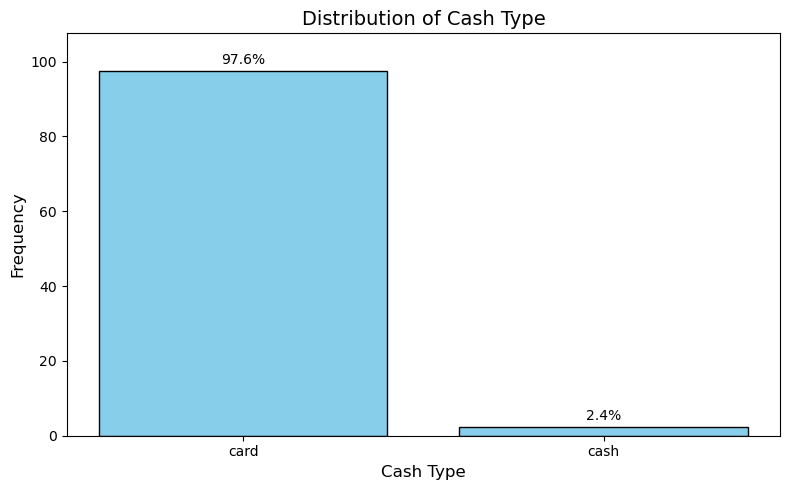

In [53]:
# checking the distribution
# Calculating value counts 

valCnt = coffeedata['cash_type'].value_counts(normalize=True)*100
print(valCnt)
# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(valCnt.index, valCnt.values, color = 'skyblue', edgecolor='black')
# Adding % labels
for bar in bars :
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             height+1, f'{height:.1f}%',
             ha='center', 
             va='bottom',
             fontsize = 10)
# Labels & Titles
plt.title('Distribution of Cash Type', fontsize=14)
plt.xlabel('Cash Type', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.ylim(0, max(valCnt.values)+10)
plt.grid(False)
plt.tight_layout()
plt.show()

- 97.6% of transactions were from card users.

In [54]:
pd.DataFrame(coffeedata['coffee_name'].value_counts(normalize=True).sort_values(ascending=False).round(4)*100)

,proportion
coffee_name,
Americano with Milk,22.66
Latte,21.51
Americano,15.90
Cappuccino,13.78
Cortado,8.03
Hot Chocolate,7.76
Cocoa,6.68
Espresso,3.69


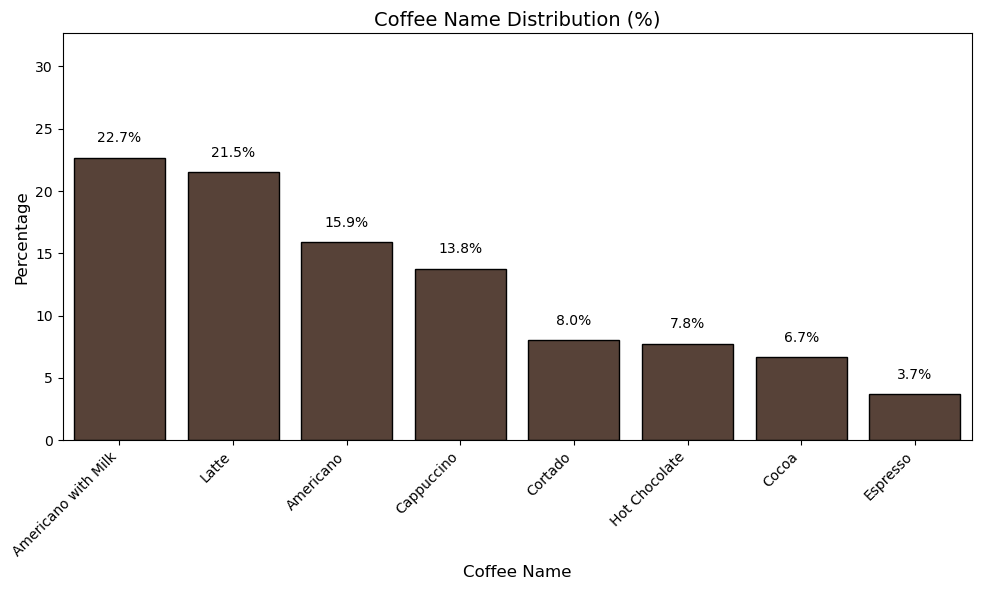

In [55]:
# Creating Pct DF
coffee_pct = (
    coffeedata['coffee_name']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename('percentage')
    .reset_index()
    .rename(columns={'index':'coffee_name'})
)
# Plotting Bar Chart using seaborn
plt.figure(figsize= (10,6))
sns.barplot(
    data = coffee_pct,
    x='coffee_name',
    y='percentage',
    color='#5C4033',
    edgecolor="black"
)
# Adding percentage labels
for i, row in coffee_pct.iterrows():
    plt.text(i, row['percentage']+1, f"{row['percentage']:.1f}%", ha='center', va='bottom', fontsize=10)
# Customizing chart
plt.title("Coffee Name Distribution (%)", fontsize = 14)
plt.xlabel("Coffee Name", fontsize=12)
plt.ylabel("Percentage", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, coffee_pct['percentage'].max()+10)
plt.tight_layout()
plt.show()

- Converting Datetime from object to Datetime format and creating new date-time features


In [56]:
# Convert to datetime
coffeedata[['date', 'datetime']] = coffeedata[['date', 'datetime']].apply(pd.to_datetime)
# Extract time features
coffeedata = coffeedata.assign(
    month = coffeedata['date'].dt.to_period('M').astype(str),
    day = coffeedata['date'].dt.dayofweek,  # 0 = Monday
    weekdayname = coffeedata['date'].dt.day_name(),
    hour = coffeedata['datetime'].dt.hour.astype(str)
)
# Preview
coffeedata.head()

,date,datetime,cash_type,card,money,coffee_name,month,day,weekdayname,hour
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,2024-03,4,Friday,10
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024-03,4,Friday,12
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024-03,4,Friday,12
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,2024-03,4,Friday,13
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,2024-03,4,Friday,13


- Checking revenue by product

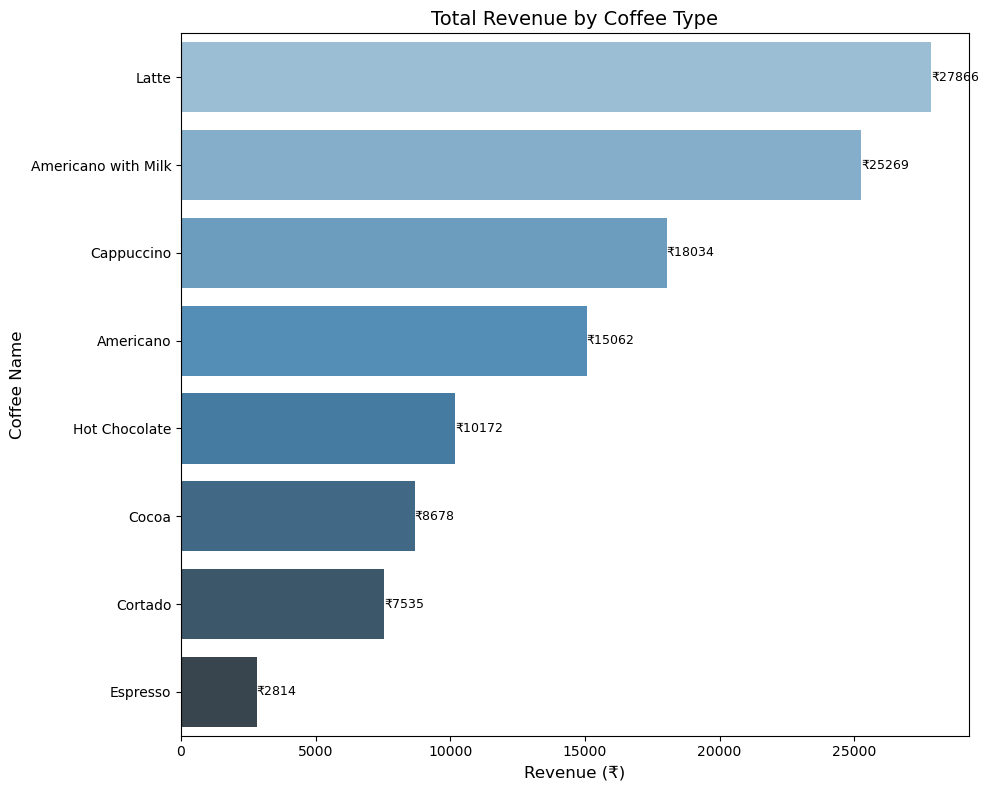

In [57]:
# Aggregating revenue by product
revenuedata = (
    coffeedata.groupby('coffee_name',  as_index=False)['money']
    .sum()
    .sort_values(by='money', ascending=False)
)

# Plotting with Seaborn
plt.figure(figsize=(10,8))
ax = sns.barplot(
    data=revenuedata,
    x='money',
    y='coffee_name',
    palette='Blues_d'
)
# Adding bar labels
for container in ax.containers:
    ax.bar_label(container,fmt='₹%.0f', fontsize=9, label_type='edge')

# Customizing
plt.title('Total Revenue by Coffee Type', fontsize=14)
plt.xlabel('Revenue (₹)', fontsize=12)
plt.ylabel('Coffee Name', fontsize=12)
plt.tight_layout()
plt.show()


Latte has been the product with highest revenue while espresso being the least.

------------------------------------------------------
#### Checking Monthly data now

In [58]:
monthlySales = (
    coffeedata
    .groupby(['month', 'coffee_name'], as_index=False)
    .size()
    .rename(columns={'size':'count'})
    .pivot(index='month', columns='coffee_name', values='count')
    .fillna(0)
    .astype(int)
    .reset_index()
)
monthlySales.head()

coffee_name,month,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
0,2024-03,36,34,20,6,30,10,22,48
1,2024-04,35,42,43,6,19,7,13,31
2,2024-05,48,58,55,9,17,8,14,58
3,2024-06,14,69,46,5,19,10,14,50
4,2024-07,36,65,32,9,14,14,11,56


In [59]:
monthlySales.describe().T.loc[:,['min','max']]

,min,max
coffee_name,,
Americano,14.0,117.0
Americano with Milk,34.0,104.0
Cappuccino,20.0,55.0
Cocoa,5.0,56.0
Cortado,2.0,41.0
Espresso,3.0,17.0
Hot Chocolate,6.0,58.0
Latte,31.0,120.0


- Let's Visualize !
- Plotting Heatmap

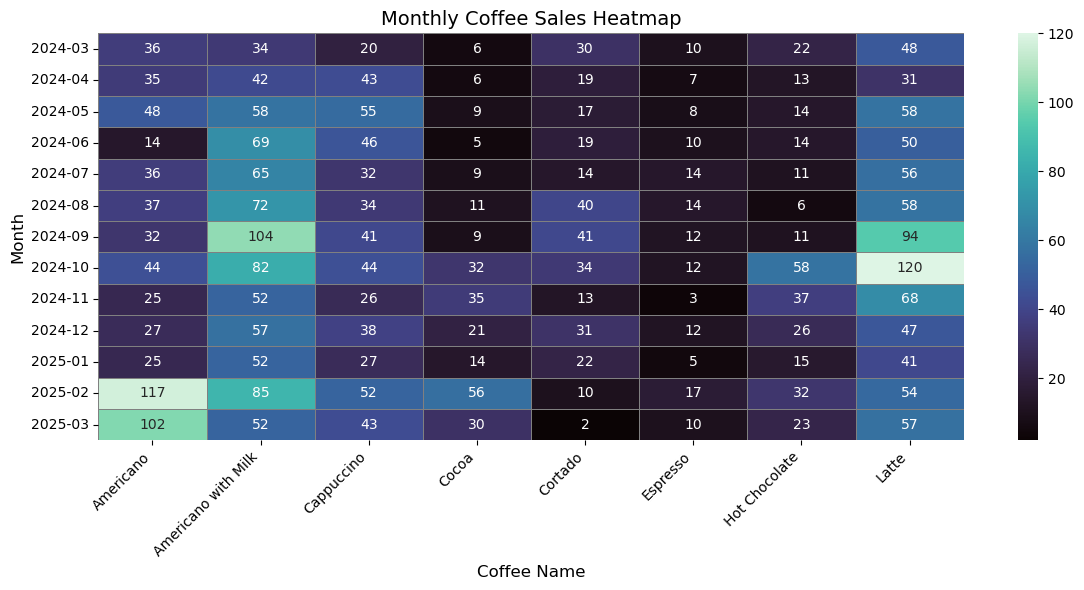

In [60]:
# setting index to month for heatmap
heatmapData = monthlySales.set_index('month')
# Plot
plt.figure(figsize = (12,6))
sns.heatmap(
    heatmapData,
    annot = True,
    fmt='d',
    cmap='mako',
    linewidth=0.5,
    linecolor='gray'
)
# Customizations
plt.title('Monthly Coffee Sales Heatmap', fontsize=14)
plt.xlabel('Coffee Name', fontsize=12)
plt.ylabel('Month', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Plotting a line chart

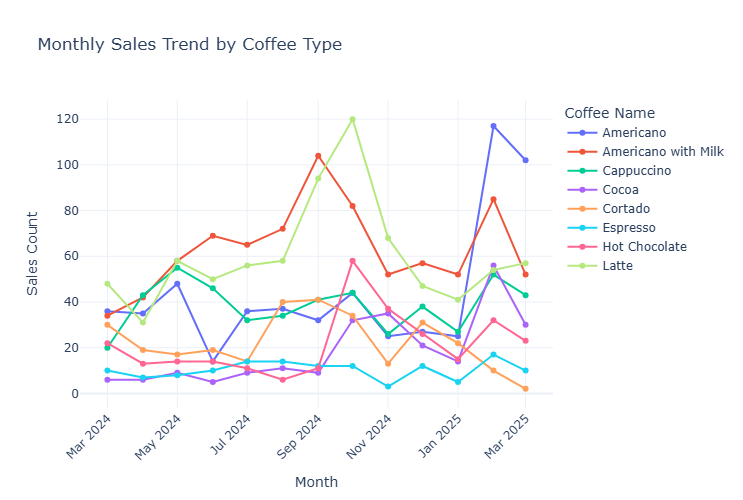

In [61]:
# reshaping monthlySales for Plotly
monthlyLong = monthlySales.melt(id_vars='month', var_name='coffee_name', value_name='sales_count')
# Creating the chart
fig = px.line(
    monthlyLong,
    x='month',
    y='sales_count',
    color='coffee_name',
    markers=True,
    title='Monthly Sales Trend by Coffee Type',
    labels={'sales_count':'Sales Count', 'month':'Month','coffee_name':'Coffee Name'},
    hover_data={'sales_count':True, 'month':True, 'coffee_name':True}
)
fig.update_layout(
    xaxis_tickangle=-45,
    legend_title='Coffee Name',
    template='plotly_white',
    height = 500
)
fig.show()

We can infer from above that Latte, Americano with Milk and Cappuccino are the top selling ones.

In [62]:
coffeedata.head()

,date,datetime,cash_type,card,money,coffee_name,month,day,weekdayname,hour
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,2024-03,4,Friday,10
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024-03,4,Friday,12
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024-03,4,Friday,12
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,2024-03,4,Friday,13
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,2024-03,4,Friday,13


#### Checking Weekly Data

In [63]:
# Weekday Sales Aggregation
weekdaySales = (
    coffeedata
    .groupby('day', as_index=False)
    .size()
    .rename(columns={'size': 'count'})
    .assign(weekday_name=lambda df: df['day'].map({0: 'Mon', 1: 'Tue', 2: 'Wed',3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}))
    .sort_values('day')
)
weekdaySales.head(7)

,day,count,weekday_name
0,0,561,Mon
1,1,585,Tue
2,2,510,Wed
3,3,520,Thu
4,4,544,Fri
5,5,482,Sat
6,6,434,Sun


- Let's plot a bar graph

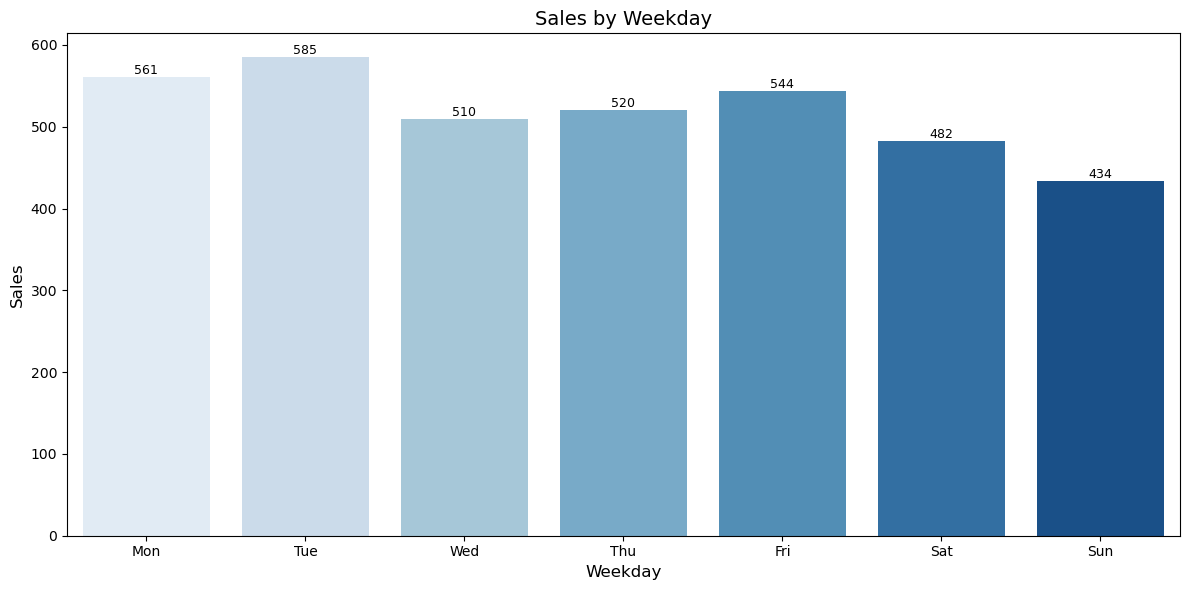

In [64]:
# Plot
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data = weekdaySales,
    x='weekday_name',
    y='count',
    palette='Blues'
)
# Bar Labels
for container in ax.containers:
    ax.bar_label(container, fontsize=9)
# Cusotmizations
plt.title('Sales by Weekday', fontsize=14)
plt.xlabel('Weekday', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Mondays and Tuesdays have recorded the highest sales counts, followed by Thursdays.

- Weekly Sales in respective months

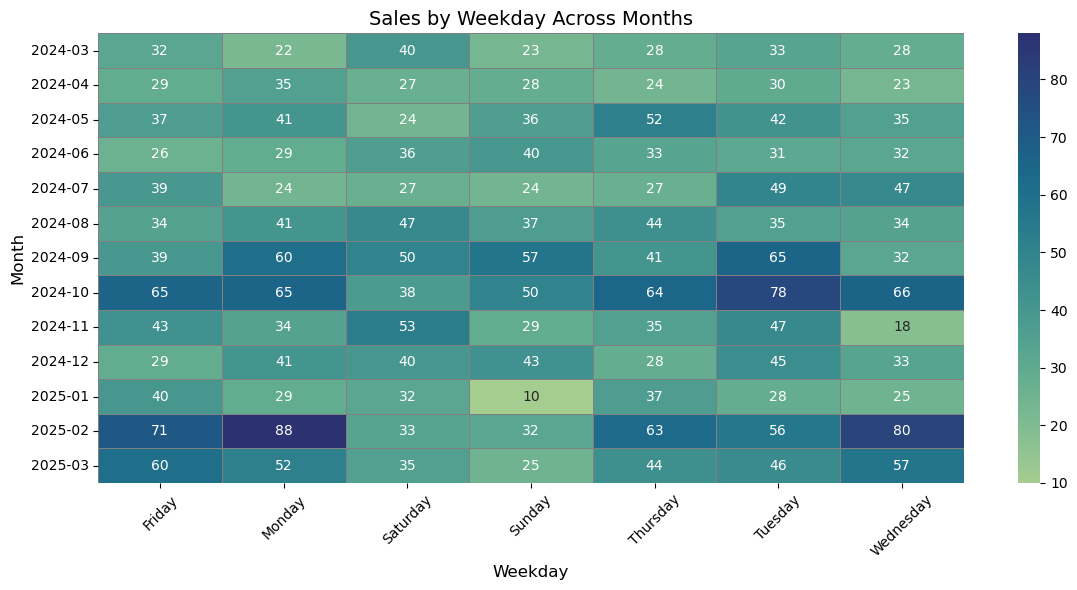

In [68]:
# Aggregating Sales by Month and weekday
weekdayMonthSales = (
    coffeedata
    .groupby(['month', 'weekdayname'], as_index=False)
    .size()
    .rename(columns={'size':'count'})
)
# Pivoting for heatmap
heatmapData = weekdayMonthSales.pivot(index='month', columns='weekdayname', values='count').fillna(0)

# Plotting Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmapData,
    annot=True,
    fmt='d',
    cmap='crest',
    linewidths=0.5,
    linecolor='gray'
)

# Customizations
plt.title('Sales by Weekday Across Months', fontsize=14)
plt.xlabel('Weekday', fontsize=12)
plt.ylabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Lets breakdown Sales of Coffee Names Each day using the above heatmap.

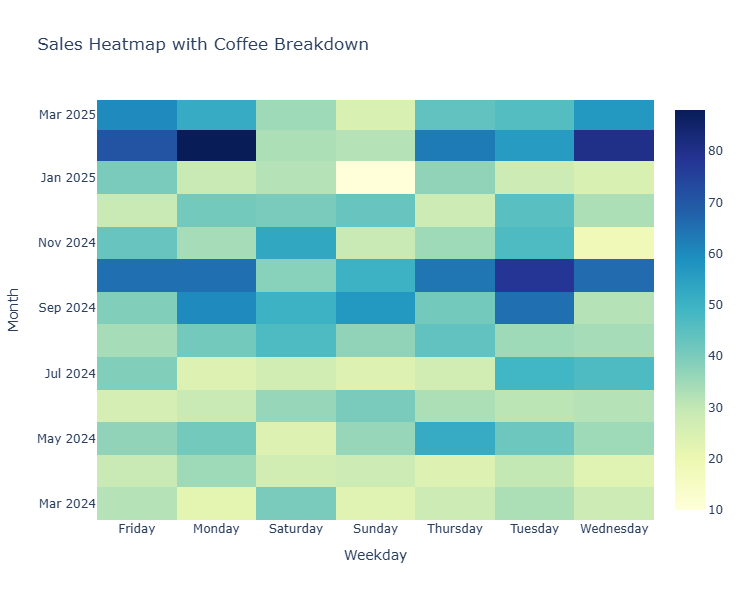

In [69]:
# Aggregating coffee sales by month and weekday
coffeeSales = (
    coffeedata
    .groupby(['month', 'weekdayname', 'coffee_name'], as_index=False)
    .size()
    .rename(columns={'size':'count'})
)

# Hover Texts
hoverText = (
    coffeeSales
    .groupby(['month', 'weekdayname'])
    .apply(lambda group: '<br>'.join(f"{row['coffee_name']}:{row['count']}" for _, row in group.iterrows()))
    .to_dict()
)

# Pivoting for the heatmap base
heatmap_data = (
    coffeeSales
    .groupby(['month','weekdayname'], as_index=False)['count']
    .sum()
    .pivot(index='month', columns='weekdayname', values='count')
    .fillna(0)
)

# Debugging the weekday order ( Previously, the weekdays didn't show in order)
#weekday_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
#heatmap_data = heatmap_data[weekday_order] -- Working on it.

# Creating hovertext matrix
hoverMatrix = [
    [hoverText.get((month, weekday),'') for weekday in heatmap_data.columns]
    for month in heatmap_data.index
]

#Building Plotly Interactive HeatMap
fig = go.Figure(data=go.Heatmap(
    z=heatmap_data.values,
    x=heatmap_data.columns,
    y=heatmap_data.index,
    text=hoverMatrix,
    hoverinfo='text',
    colorscale = 'YlGnBu'
))

# Customizations
fig.update_layout(
    title = 'Sales Heatmap with Coffee Breakdown',
    xaxis_title='Weekday',
    yaxis_title='Month',
    height=600
)
fig.show()


# Time Series Modeling
- Let's start with Time series modeling.

In [356]:
# Importing necessary libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose as sd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

### Performing Time Series based on three models:
- ARIMA
- SARIMAX
- Auto ARIMA

Before starting with modeling we have to prepare the data accordingly.

#### Data Preparation

In [71]:
# Let's view the data first.
coffeedata.head(10)

,date,datetime,cash_type,card,money,coffee_name,month,day,weekdayname,hour
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,2024-03,4,Friday,10
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024-03,4,Friday,12
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024-03,4,Friday,12
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,2024-03,4,Friday,13
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,2024-03,4,Friday,13
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,33.8,Americano with Milk,2024-03,4,Friday,15
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.7,Hot Chocolate,2024-03,4,Friday,16
7,2024-03-01,2024-03-01 18:39:03.580,card,ANON-0000-0000-0007,33.8,Americano with Milk,2024-03,4,Friday,18
8,2024-03-01,2024-03-01 19:22:01.762,card,ANON-0000-0000-0008,38.7,Cocoa,2024-03,4,Friday,19
9,2024-03-01,2024-03-01 19:23:15.887,card,ANON-0000-0000-0008,33.8,Americano with Milk,2024-03,4,Friday,19


In [72]:
# Cup count
dailySales = (
    coffeedata
    .groupby('date')
    .size()
    .reset_index(name='cups')
    .sort_values('date')
)
dailySales.head()

,date,cups
0,2024-03-01,11
1,2024-03-02,7
2,2024-03-03,10
3,2024-03-04,4
4,2024-03-05,9


- The above dataframe only contains dates where the coffee is sold with their number of cups.

In [73]:
# Date Range
dateRange = pd.date_range(start=dailySales['date'].min(), end=dailySales['date'].max())
compDate = pd.DataFrame({'date':dateRange})
compDate.head()

,date
0,2024-03-01
1,2024-03-02
2,2024-03-03
3,2024-03-04
4,2024-03-05


In [74]:
# Joining the Daily Sales Data and Complete Date
compSalesData = pd.merge(compDate, dailySales, on='date', how='left')
compSalesData['cups'].fillna(0, inplace=True)
compSalesData.set_index('date', inplace=True)
compSalesData.head()

,cups
date,
2024-03-01,11.0
2024-03-02,7.0
2024-03-03,10.0
2024-03-04,4.0
2024-03-05,9.0


- This Data Frame contains every date from the start till the end with number of cups of coffee sold. Some dates might have zero values. 

#### Time Series Visualization

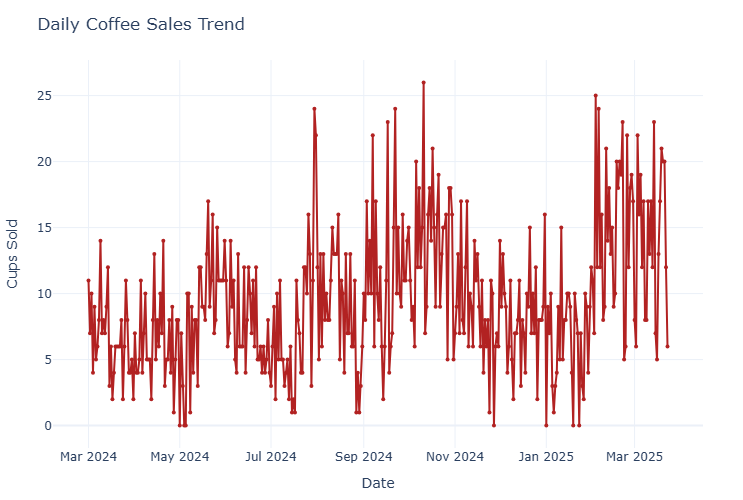

In [76]:
fig = go.Figure()

# Adding lines and markers
fig.add_trace(go.Scatter(
    x=compSalesData.index,
    y=compSalesData['cups'],
    mode='lines+markers',
    name='Cups Sold',
    line=dict(color='firebrick', width=2),
    marker=dict(size=4),
    hovertemplate='Date: %{x}<br>Cups Sold: %{y}<extra></extra>'
))

# Customizations
fig.update_layout(
    title='Daily Coffee Sales Trend',
    xaxis_title='Date',
    yaxis_title='Cups Sold',
    template='plotly_white',
    height=500,
    margin=dict(l=40, r=40, t=60, b=40),
    hovermode='x unified'
)

##### Before proceeding further let's look at the Decompositions.

In [89]:
# Time Series Decomposition
res = sd(compSalesData['cups'], model='additive', period=7)

In [170]:
print("------------ Actuals Observed ------------")
print(res.observed.head(7))
print("------------ Trends Data ------------")
print(res.trend.head(7))
print("------------ Seasonal Data ------------")
print(res.seasonal.head(7))
print("------------ Residual Data ------------")
print(res.resid.head(7))

------------ Actuals Observed ------------
date
2024-03-01    11.0
2024-03-02     7.0
2024-03-03    10.0
2024-03-04     4.0
2024-03-05     9.0
2024-03-06     5.0
2024-03-07     6.0
Name: cups, dtype: float64
------------ Trends Data ------------
date
2024-03-01         NaN
2024-03-02         NaN
2024-03-03         NaN
2024-03-04    7.428571
2024-03-05    7.000000
2024-03-06    8.000000
2024-03-07    7.571429
Name: trend, dtype: float64
------------ Seasonal Data ------------
date
2024-03-01    0.221721
2024-03-02   -0.725369
2024-03-03   -1.601031
2024-03-04    0.856689
2024-03-05    1.269676
2024-03-06   -0.106947
2024-03-07    0.085261
Name: seasonal, dtype: float64
------------ Residual Data ------------
date
2024-03-01         NaN
2024-03-02         NaN
2024-03-03         NaN
2024-03-04   -4.285261
2024-03-05    0.730324
2024-03-06   -2.893053
2024-03-07   -1.656689
Name: resid, dtype: float64


##### Plotting the above :

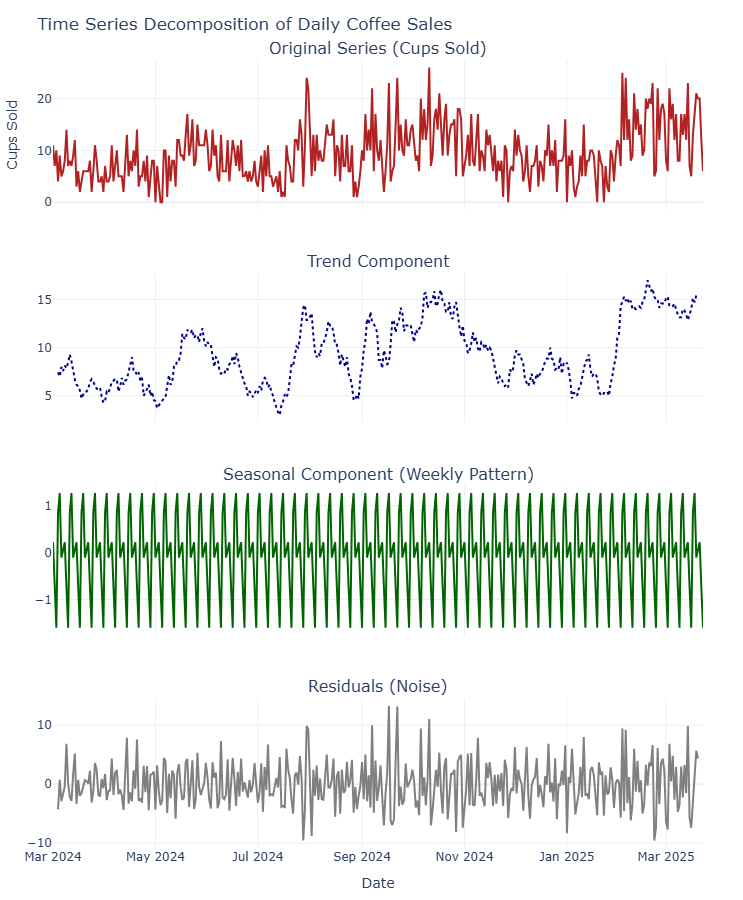

In [108]:
# Creating subplots
from plotly.subplots import make_subplots
fig = make_subplots(rows=4, cols=1, shared_xaxes=True,
                    subplot_titles=["Original Series (Cups Sold)", "Trend Component","Seasonal Component (Weekly Pattern)","Residuals (Noise)"],vertical_spacing=0.08)

# Observed
fig.add_trace(go.Scatter(
    x=res.observed.index,
    y=res.observed,
    mode='lines',
    name='Observed',
    line=dict(color='firebrick')
),row=1, col=1)

# Trend
fig.add_trace(go.Scatter(
    x=res.trend.index,
    y=res.trend,
    mode='lines',
    name='Trend',
    line=dict(color='darkblue',
             width=2,
             dash='dot')
), row=2, col=1)

# Seasonal
fig.add_trace(go.Scatter(
    x=res.seasonal.index,
    y=res.seasonal,
    mode='lines',
    name='Seasonal',
    line=dict(color='darkgreen')
), row=3, col=1)

# Residuals
fig.add_trace(go.Scatter(
    x=res.resid.index,
    y=res.resid,
    mode='lines',
    name='Residuals',
    line=dict(color='gray')
), row=4, col=1)

# Layout tweaks
fig.update_layout(
    height=900,
    title='Time Series Decomposition of Daily Coffee Sales',
    template='plotly_white',
    showlegend=False,
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.update_xaxes(title_text='Date', row=4, col=1)
fig.update_yaxes(title_text='Cups Sold', row=1, col=1)
fig.show()


 ###### Checking if my Data is stationary, using ADF(Augmented Dickey Fuller) Test.
 - if the p value is less than 0.05 , i.e p<0.05, then my data is stationary.

In [196]:
from termcolor import colored # Trying my best to make it fancy too.
from statsmodels.tsa.stattools import adfuller
result = adfuller(compSalesData)

if result[1]>0.05:
    print(colored("The data is NOT STATIONARY. We have to start differencing/transformations.", "red"))
else:
    print(colored("The data is STATIONARY. We can proceed with ARIMA modeling.", "green"))
    print(colored(f"P-Value: {result[1]:.4f}", "blue"))


The data is STATIONARY. We can proceed with ARIMA modeling.
P-Value: 0.0295


#### Starting with ARIMA

##### Plotting ACF (AutoCorrelation Function) and PACF(Partial AutoCorrelation Function)

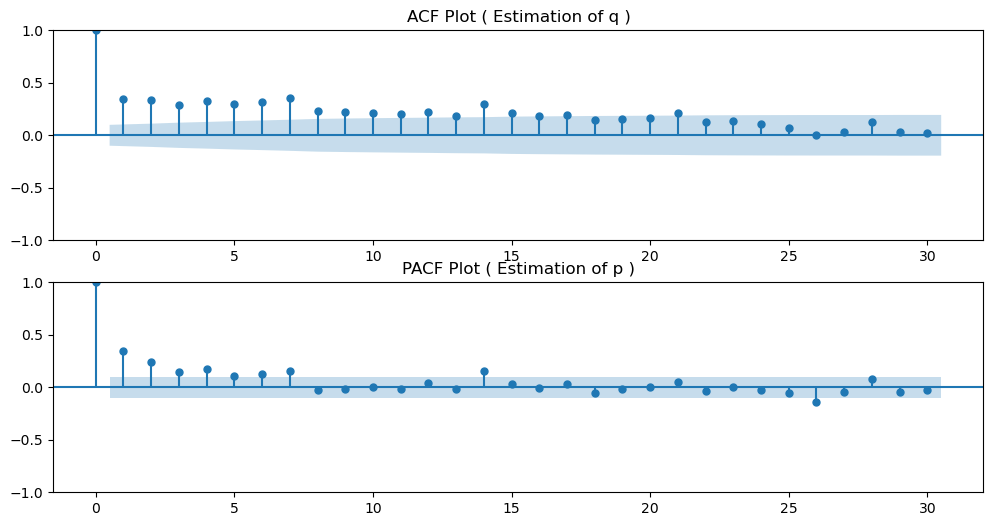

In [335]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(2,1, figsize=(12,6))
plot_acf(compSalesData['cups'], lags=30, ax=ax[0])
plot_pacf(compSalesData['cups'], lags=30, ax=ax[1])
ax[0].set_title('ACF Plot ( Estimation of q )')
ax[1].set_title('PACF Plot ( Estimation of p )')
plt.show()

In [336]:
# Train-Test Split
testsize = 7
trainsize = compSalesData.shape[0] - testsize
csdTrain = compSalesData.iloc[:trainsize]   # Complete Sales Data Training set
csdTest = compSalesData.iloc[trainsize:]   # Complete Sales Data Testing set
print(csdTrain.head())
print(csdTest.head())

            cups
date            
2024-03-01  11.0
2024-03-02   7.0
2024-03-03  10.0
2024-03-04   4.0
2024-03-05   9.0
            cups
date            
2025-03-17  13.0
2025-03-18  17.0
2025-03-19  21.0
2025-03-20  20.0
2025-03-21  20.0


In [337]:
# Fitting ARIMA model using manual p,d,q values
model = ARIMA(csdTrain['cups'], 
              order=(5,0,5))  # d=0 , differencing value as my data is stationary
model_fit = model.fit()

In [338]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   cups   No. Observations:                  381
Model:                 ARIMA(5, 0, 5)   Log Likelihood               -1102.664
Date:                Fri, 17 Oct 2025   AIC                           2229.327
Time:                        02:03:31   BIC                           2276.641
Sample:                    03-01-2024   HQIC                          2248.100
                         - 03-16-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3185      1.154      8.078      0.000       7.058      11.579
ar.L1          0.7298      0.046     15.964      0.000       0.640       0.819
ar.L2          0.3938      0.059      6.648      0.000       0.278       0.510
ar.L3         -0.3707      0.061     -6.042      0.000      -0.491      -0.250
ar.L4         -0.7214      0.068    -10.650      0.000      -0.854      -0.589
ar.L5          0.8690      0.046     18.940      0.000       0.779       0.959
ma.L1         -0.6170      0.058    -10.554      0.000      -0.732      -0.502
ma.L2         -0.3643      0.039     -9.230      0.000      -0.442      -0.287
ma.L3          0.3563      0.044      8.088      0.000       0.270       0.443
ma.L4          0.8438      0.048     17.665      0.000       0.750       0.937
ma.L5         -0.7446      0.060    -12.438      0.000      -0.862      -0.627
sigma2        18.9242      1.323     14.307      0.000      16.332      21.517
===================================================================================
Ljung-Box (L1) (Q):                   0.16   Jarque-Bera (JB):                19.94
Prob(Q):                              0.69   Prob(JB):                         0.00
Heteroskedasticity (H):               1.90   Skew:                             0.49
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [339]:
# Forecasting
preds_arima = model_fit.forecast(steps=testsize)
csdTest['arima_pred'] = preds_arima
csdTest

,cups,arima_pred
date,,
2025-03-17,13.0,10.842848
2025-03-18,17.0,12.440498
2025-03-19,21.0,13.522551
2025-03-20,20.0,13.116398
2025-03-21,20.0,11.961077
2025-03-22,12.0,10.256741
2025-03-23,6.0,9.316186


In [340]:
# Model Evaluation
mae_arima = mean_absolute_error(csdTest['cups'], preds_arima)
print(f'ARIMA MAE : {mae_arima:.2f}')

ARIMA MAE : 4.88


In [341]:
# Creating a function for plots in plotly
def forecast_actuals(df_train, df_test, forecast, title='Forecast v/s Actuals'):

    fig = go.Figure()

    # Train data
    fig.add_trace(go.Scatter(
        x=df_train.index,
        y=df_train['cups'],
        mode='lines',
        name='Train',
        line=dict(color='royalblue')
    ))

    # Test data (actual)
    fig.add_trace(go.Scatter(
        x=df_test.index,
        y=df_test['cups'],
        mode='lines',
        name='Test',
        line=dict(color='darkorange')
    ))

    # Forecast
    fig.add_trace(go.Scatter(
        x=df_test.index,
        y=df_test[forecast],
        mode='lines+markers',
        name='Forecast',
        line=dict(color='firebrick', dash='dash'),
        marker=dict(size=4),
        hovertemplate='Date: %{x}<br>Forecasted Cups: %{y}<extra></extra>'
    ))

    # Layout
    fig.update_layout(
        title=title,
        xaxis_title='Date',
        yaxis_title='Cups Sold',
        template='plotly_white',
        height=600,
        margin=dict(l=40, r=40, t=60, b=40),
        hovermode='x unified',
        legend=dict(x=0.01, y=0.99)
    )

    fig.update_yaxes(range=[0, max(df_test[['cups', forecast]].max()) + 5])
    fig.show()

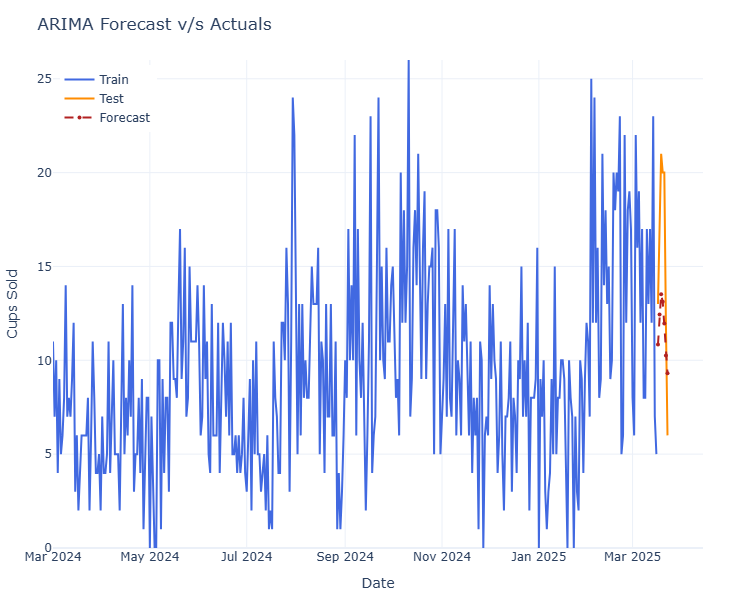

In [342]:
forecast_actuals(csdTrain, csdTest, forecast = 'arima_pred', title="ARIMA Forecast v/s Actuals")

##### The MAE is too high for this data which is 4.88.
#### Proceeding with SARIMAX
- In the previous plots of ACF and PACF we see that there's a sudden drop in lag at '2' & '1' respectively. Thus, choosing my q=1 and p=2, and because my data has seasonality at s=7 thus taking d=1.

In [343]:
model_sm = SARIMAX(csdTrain['cups'], 
                   order=(5,0,5), 
                   seasonal_order=(1,1,2,7))
modelsm_fit = model_sm.fit()
modelsm_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                                   cups   No. Observations:                  381
Model:             SARIMAX(5, 0, 5)x(1, 1, [1, 2], 7)   Log Likelihood               -1087.377
Date:                                Fri, 17 Oct 2025   AIC                           2202.754
Time:                                        02:03:42   BIC                           2257.694
Sample:                                    03-01-2024   HQIC                          2224.568
                                         - 03-16-2025                                         
Covariance Type:                                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4419      0.236      1.875      0.061      -0.020       0.904
ar.L2          1.0943      0.318      3.446      0.001       0.472       1.717
ar.L3         -1.1543      0.102    -11.331      0.000      -1.354      -0.955
ar.L4         -0.3258      0.265     -1.230      0.219      -0.845       0.193
ar.L5          0.7862      0.191      4.120      0.000       0.412       1.160
ma.L1         -0.3139      0.244     -1.289      0.198      -0.791       0.164
ma.L2         -1.0092      0.283     -3.570      0.000      -1.563      -0.455
ma.L3          1.0790      0.103     10.441      0.000       0.876       1.282
ma.L4          0.4696      0.248      1.891      0.059      -0.017       0.956
ma.L5         -0.6318      0.146     -4.325      0.000      -0.918      -0.346
ar.S.L7       -0.4394      3.675     -0.120      0.905      -7.642       6.763
ma.S.L7       -0.4531      3.692     -0.123      0.902      -7.688       6.782
ma.S.L14      -0.3778      3.272     -0.115      0.908      -6.790       6.035
sigma2        18.7398      1.354     13.842      0.000      16.086      21.393
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):                15.68
Prob(Q):                              0.62   Prob(JB):                         0.00
Heteroskedasticity (H):               1.54   Skew:                             0.42
Prob(H) (two-sided):                  0.02   Kurtosis:                         3.56
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [344]:
forecast_sm = modelsm_fit.forecast(steps=len(csdTest))
forecast_sm

2025-03-17    14.901343
2025-03-18    13.297215
2025-03-19    14.801320
2025-03-20    14.215386
2025-03-21    15.650818
2025-03-22     9.719421
2025-03-23     6.296048
Freq: D, Name: predicted_mean, dtype: float64

In [351]:
csdTest['sm_forecast'] = forecast_sm
csdTest

,cups,arima_pred,sm_forecast
date,,,
2025-03-17,13.0,10.842848,14.901343
2025-03-18,17.0,12.440498,13.297215
2025-03-19,21.0,13.522551,14.801320
2025-03-20,20.0,13.116398,14.215386
2025-03-21,20.0,11.961077,15.650818
2025-03-22,12.0,10.256741,9.719421
2025-03-23,6.0,9.316186,6.296048


- Now the error has seemed to improve significantly. Plotting the forecast now.

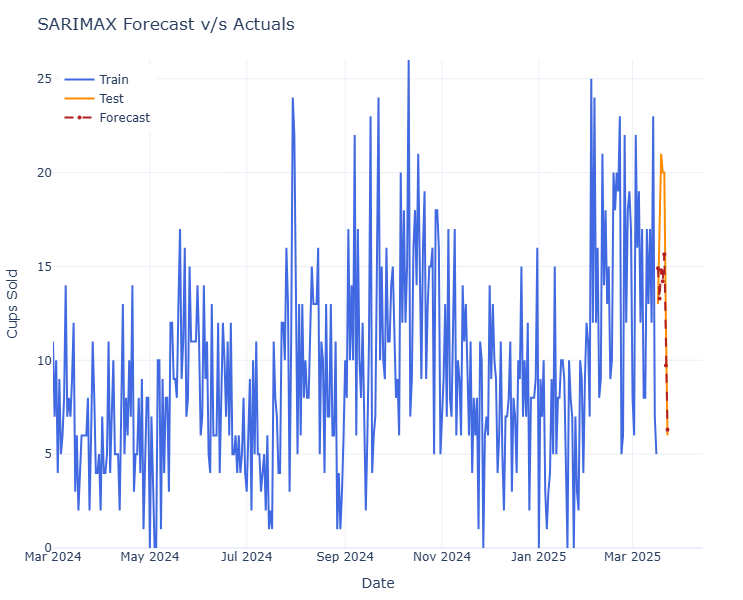

In [352]:
# Used the same function forecast v/s actuals
forecast_actuals(csdTrain, csdTest, forecast = 'sm_forecast', title="SARIMAX Forecast v/s Actuals")

###### Lets calculate the errors and see how the model is performing.


##### Mean Absolute Error (MAE)


In [354]:
sm_mae = mean_absolute_error(csdTest['cups'], csdTest['sm_forecast'])
print(f"MAE: {sm_mae: .2f}")

MAE:  3.50


##### Root Mean Squared Error (RMSE)

In [359]:
sm_mse = mean_squared_error(csdTest['cups'], csdTest['sm_forecast'])
sm_rmse = sm_mse**0.5
print(f"MAE: {sm_rmse: .2f}")

MAE:  4.03


In [360]:
model_auto = auto_arima(csdTrain, 
                        seasonal=True,
                        m=7, trace=True, 
                        error_action='ignore', 
                        suppress_warnings=True, 
                        stepwise =True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=2231.656, Time=1.76 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=2440.275, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=2330.036, Time=0.22 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=2233.936, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=2438.278, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=2239.005, Time=0.73 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=2238.030, Time=0.83 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=2232.902, Time=4.43 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=2232.843, Time=4.33 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=2240.755, Time=0.31 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=2236.945, Time=2.19 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=2235.121, Time=2.12 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=2233.252, Time=4.34 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=2229.867, Time=0.93 sec
 ARIMA(1,1,2)(0,0,1)[7] intercept

In [361]:
forecast_auto = model_auto.predict(n_periods=len(csdTest))
csdTest['auto_forecast'] = forecast_auto

In [362]:
csdTest

,cups,arima_pred,sm_forecast,auto_forecast
date,,,,
2025-03-17,13.0,10.842848,14.901343,15.339486
2025-03-18,17.0,12.440498,13.297215,13.169362
2025-03-19,21.0,13.522551,14.801320,14.546438
2025-03-20,20.0,13.116398,14.215386,13.062993
2025-03-21,20.0,11.961077,15.650818,15.003056
2025-03-22,12.0,10.256741,9.719421,10.789369
2025-03-23,6.0,9.316186,6.296048,10.267654


In [364]:
mae_auto = mean_absolute_error(csdTest['cups'],csdTest['auto_forecast'])
print(f"Auto ARIMA MAE: {mae_auto: .2f}")

Auto ARIMA MAE:  4.29


In [365]:
rmse_auto = mean_squared_error(csdTest['cups'], csdTest['auto_forecast'])**0.5
print(f"Auto ARIMA RMSE: {rmse_auto: .2f}")

Auto ARIMA RMSE:  4.70


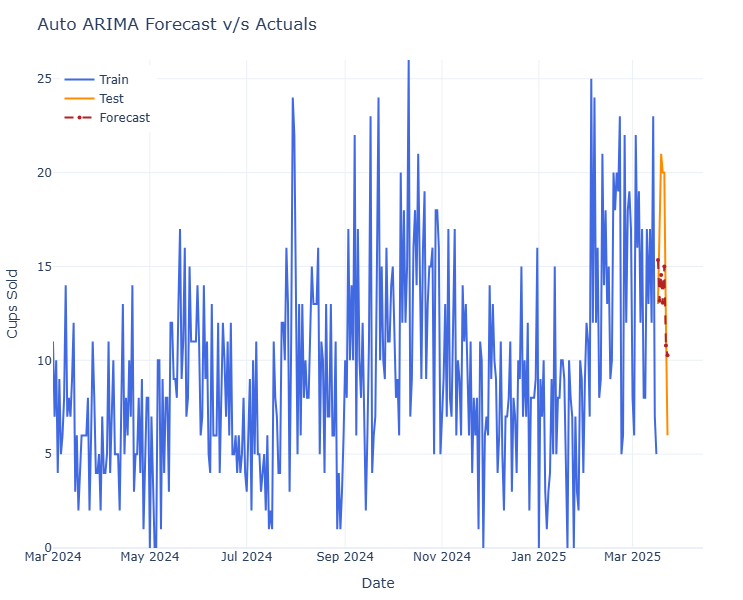

In [366]:
forecast_actuals(csdTrain, csdTest, forecast='auto_forecast', title="Auto ARIMA Forecast v/s Actuals")